In [63]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [31]:
def f_dumbbell(point, source_location):
    vdiff = abs(point[1] - source_location[1])
    hdiff = abs(point[0] - source_location[0])
    if vdiff <= 3:
        if hdiff <= vdiff:
            return 1/(1 + vdiff)
    return 0


In [61]:
class InfotaxisProblem:
    def __init__(self, grid_size, source_location, start_location, f, selector):
        self.grid_size = grid_size
        self.source_location = source_location
        self.start_location = start_location
        self.belief = np.full((grid_size, grid_size), 1/(grid_size**2))
        self.path = [] #composed of a tuple consisting of the location and the 1 or 0 of the sample result
        self.f = f
        self.selector = selector
    
    def step(self):
        next_location = self.selector(self.belief, self.f, self.path if len(self.path) > 0 else [[self.start_location]])
        sample_result = self.sample_point(next_location)
        self.path.append((next_location, sample_result))
        self.update_belief(next_location, sample_result)
    
    def sample_point(self, point):
        diceroll = np.random.uniform(0, 1)

        return 1 if diceroll < self.f(point, self.source_location) else 0
    
    def update_belief(self, point, sample_result):
        for i in range(self.grid_size):
            for j in range(self.grid_size):
                p = (j, i)
                if sample_result == 1:
                    self.belief[i][j] *= self.f(point, p)
                else:
                    self.belief[i][j] *= (1 - self.f(point, p))
        
        self.belief /= np.sum(self.belief)
    
    def plot_current(self, show=False, savename=None):
        #plot the current belief, the path taken, and the source location
        plt.imshow(self.belief, cmap='viridis', interpolation='nearest')
        plt.scatter(self.source_location[0], self.source_location[1], c='green', label='Source Location')
        path_x = [loc[0] for loc, _ in self.path]
        path_y = [loc[1] for loc, _ in self.path]
        plt.plot(path_x, path_y, c='blue', label='Path Taken')
        plt.scatter(path_x, path_y, c='blue')
        plt.scatter(self.path[-1][0][0], self.path[-1][0][1], c='orange')
        plt.legend()
        plt.colorbar(label='belief')
        if show:
            plt.title('Current Belief and Path')
            plt.show()
        if savename is not None:
            os.makedirs(savename, exist_ok=True)
            plt.savefig(f'{savename}/{savename}_{len(self.path)}.png', bbox_inches='tight', pad_inches=0.1)


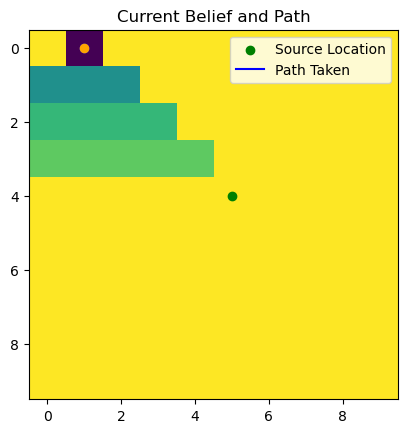

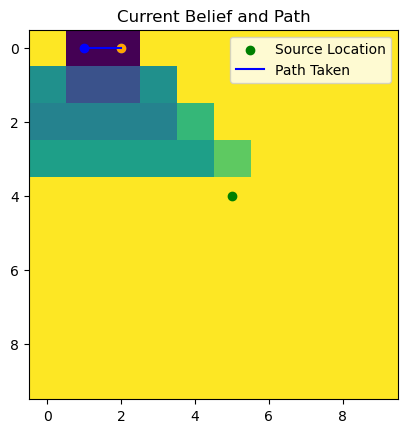

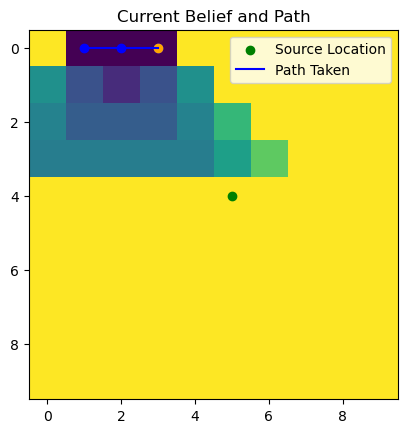

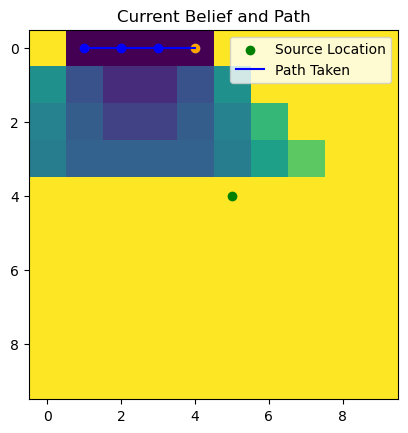

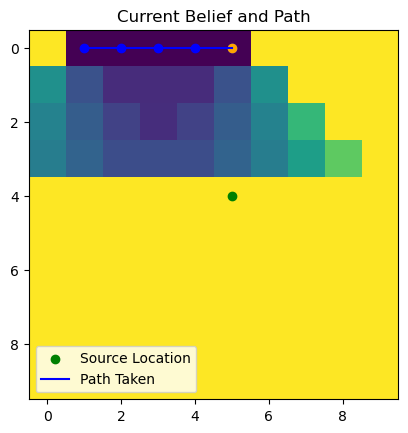

In [44]:
# Infotaxis test that just moves left to right across the grid
def selector_left_to_right(belief, f, path):
    last_location = path[-1][0]
    next_x = (last_location[0] + 1) % belief.shape[0]
    return (next_x, last_location[1])

test_problem = InfotaxisProblem(grid_size=10, source_location=(5, 4), start_location=(0, 0), f=f_dumbbell, selector=selector_left_to_right)
for _ in range(5):
    test_problem.step()
    test_problem.plot_current(show=True)

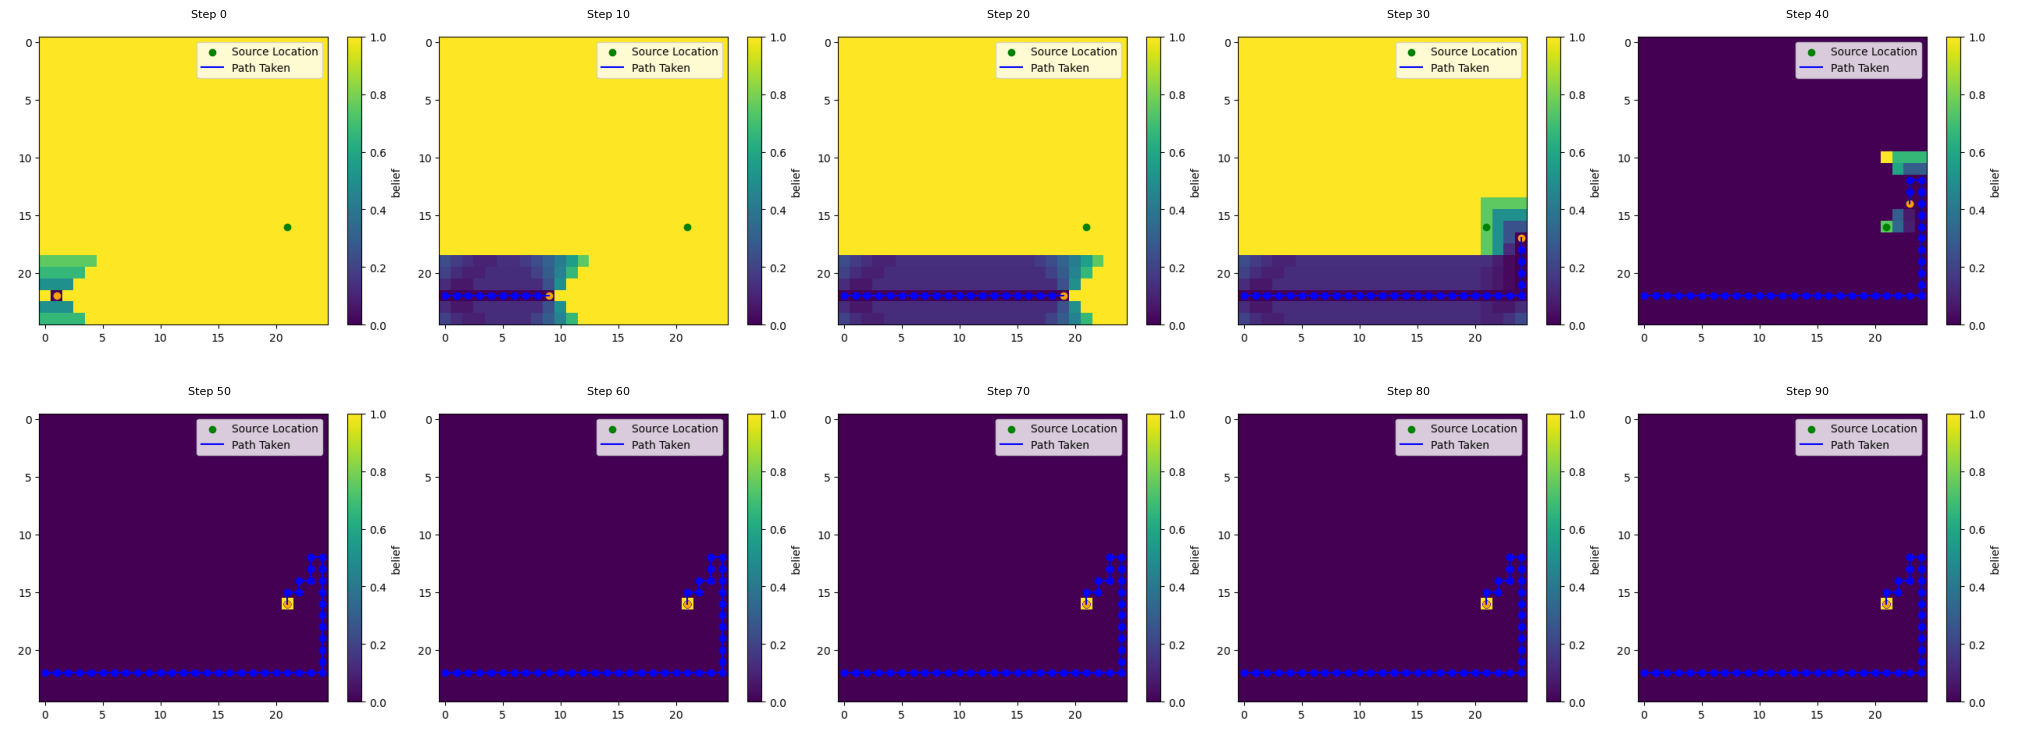

In [87]:
def max_belief_selector(belief, f, path):
    last = path[-1][0]
    
    # Find all cells sharing the maximum belief value
    max_val = np.max(belief)
    max_mask = np.isclose(belief, max_val)
    max_positions = np.argwhere(max_mask)  # returns (row, col) pairs
    
    # Among tied cells, pick the nearest one by Manhattan distance
    nearest = min(max_positions, key=lambda pos: abs(pos[1] - last[0]) + abs(pos[0] - last[1]))
    max_loc = (nearest[1], nearest[0])  # (row,col) → (x,y)

    dx = max_loc[0] - last[0]
    dy = max_loc[1] - last[1]

    if abs(dx) >= abs(dy):
        return (last[0] + int(np.sign(dx)), last[1])
    else:
        return (last[0], last[1] + int(np.sign(dy)))

dim = 25
source_loc = np.random.randint(0, dim, size=2)
start_loc = np.random.randint(0, dim, size=2)

max_belief_problem = InfotaxisProblem(grid_size=25, source_location=source_loc, start_location=start_loc, f=f_dumbbell, selector=max_belief_selector)
for i in range(100):
    max_belief_problem.step()
    if i % 10 == 0:
        max_belief_problem.plot_current(savename='max_belief')
        plt.close()

# Display all 10 saved images in a 5x2 grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for idx, ax in enumerate(axes.flat):
    step_num = idx * 10
    img = plt.imread(f'max_belief/max_belief_{step_num + 1}.png')
    ax.imshow(img)
    ax.set_title(f'Step {step_num}', fontsize=8)
    ax.axis('off')

plt.tight_layout(pad=0.1)  # tighten padding between subplots
plt.show()

In [75]:
def external_belief_update(prev_belief, point, sample_result, f):
    for i in range(prev_belief.shape[0]):
        for j in range(prev_belief.shape[1]):
            p = (j, i)
            if sample_result == 1:
                prev_belief[i][j] *= f(point, p)
            else:
                prev_belief[i][j] *= (1 - f(point, p))
    
    prev_belief /= np.sum(prev_belief)
    return prev_belief

def infotaxis_selector(belief, f, path):
    current = path[-1][0]
    options = [(current[0] + dx, current[1] + dy) for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]]
    #remove options that are out of bounds
    options = [opt for opt in options if 0 <= opt[0] < belief.shape[1] and 0 <= opt[1] < belief.shape[0]]
    
    prev_surprise = 0
    for i in range(belief.shape[0]):
        for j in range(belief.shape[1]):
            prev_surprise += -1 * belief[i][j] * np.log(belief[i][j] + 1e-10)  # add small value to avoid log(0)

    best_option = -1
    best_info = -1
    for option in options:
        #calculate the expectation of p(y|x,option), p(y|x,s') in the notes
        #that is, the the distribution of possible measurements at each location, given the current belief
        tot_positive = 0
        tot_negative = 0
        for i in range(belief.shape[0]):
            for j in range(belief.shape[1]):
                x = (j, i)
                p_y_given_x_option = f(option, x)
                p_y_given_x_not_option = 1 - p_y_given_x_option

                tot_positive += belief[i][j] * p_y_given_x_option
                tot_negative += belief[i][j] * p_y_given_x_not_option

        #calculate relevent surprises
        pos_surprise = 0
        neg_surprise = 0
        belief_given_positive = external_belief_update(belief.copy(), option, 1, f)
        belief_given_negative = external_belief_update(belief.copy(), option, 0, f)
        for i in range(belief.shape[0]):
            for j in range(belief.shape[1]):
                pos_surprise += -1 * belief_given_positive[i][j] * np.log(belief_given_positive[i][j] + 1e-10)
                neg_surprise += -1 * belief_given_negative[i][j] * np.log(belief_given_negative[i][j] + 1e-10)
        
        expected_surprise = tot_positive * pos_surprise + tot_negative * neg_surprise
        info_gain = prev_surprise - expected_surprise
        if info_gain > best_info:
            best_info = info_gain
            best_option = option

    return best_option

/tmp/ipykernel_125096/269004001.py:10: RuntimeWarning: invalid value encountered in divide
  prev_belief /= np.sum(prev_belief)


77


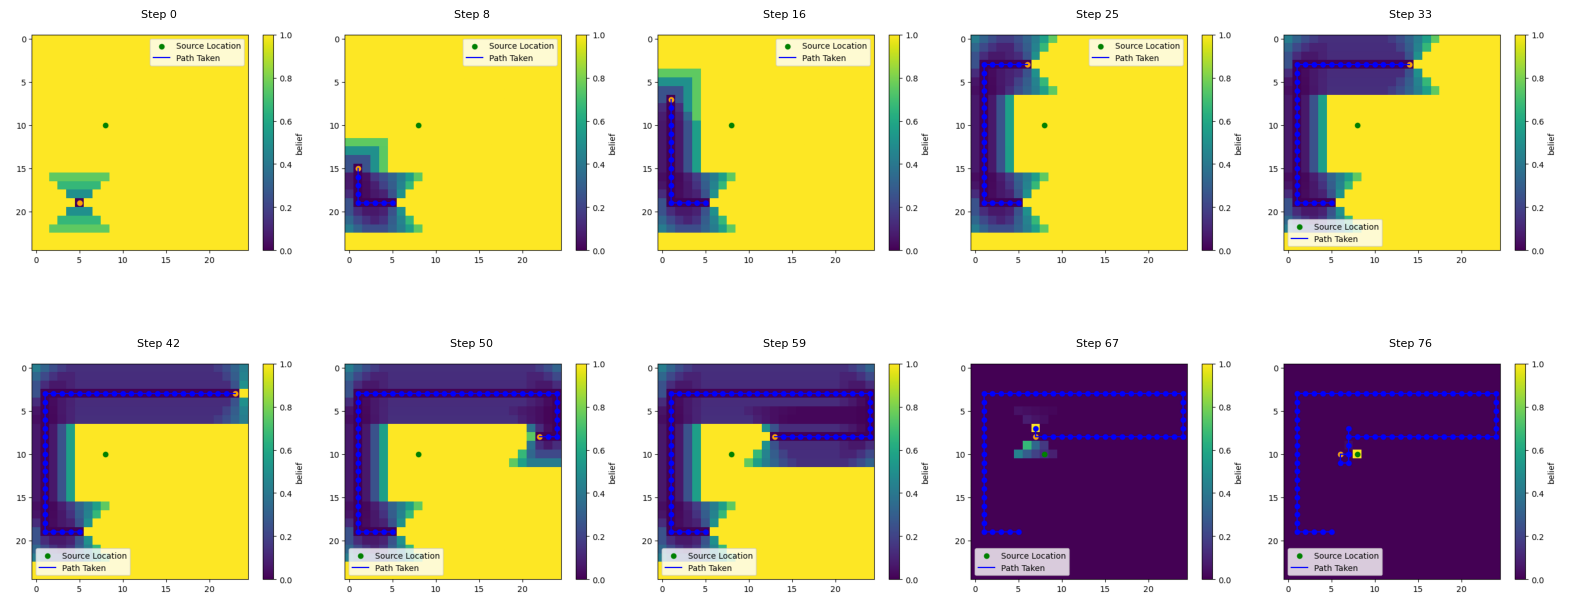

In [92]:
dim = 25
source_loc = np.random.randint(0, dim, size=2)
start_loc = np.random.randint(0, dim, size=2)

infotaxis_problem = InfotaxisProblem(grid_size=25, source_location=source_loc, start_location=start_loc, f=f_dumbbell, selector=infotaxis_selector)
step = 0
while True:
    infotaxis_problem.step()
    infotaxis_problem.plot_current(savename='infotaxis')
    plt.close()
    step += 1
    if np.max(infotaxis_problem.belief) > 0.95:  # converged when one cell dominates
        break
print(step)
# Pick 10 evenly spaced steps from 0 to final
snapshot_indices = np.linspace(0, step - 1, 10, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, idx in zip(axes.flat, snapshot_indices):
    img = plt.imread(f'infotaxis/infotaxis_{idx + 1}.png')  # +1 because filenames start at 1
    ax.imshow(img)
    ax.set_title(f'Step {idx}', fontsize=8)
    ax.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.15)
plt.show()